# Project 1 — Descriptive Analytics
## Understanding a Diamond Retailer's Inventory

**Business context:** A jewelry retailer has a catalogue of ~54,000 diamonds and wants
to understand what it actually has in stock: how diamonds are priced, which physical
characteristics drive that price, and whether the inventory naturally falls into
distinct product segments (e.g. entry-level vs. premium stones) that could inform
pricing, marketing, and merchandising decisions.

**Dataset:** `diamonds.csv` — 53,940 diamonds, each described by the "4 Cs" (carat,
cut, color, clarity) plus physical dimensions and price. This is a well-known public
dataset (distributed via the `seaborn` visualization library's example-data repository).

**Goal of this notebook:** Apply the descriptive-analytics workflow — clean the data,
explore it, visualize it, and use unsupervised learning (clustering) to *describe*
the natural segments in the catalogue. Descriptive analytics answers "what does our
data look like and what patterns already exist in it?" — it does not forecast the
future (that's predictive) or recommend actions (that's prescriptive); those are
covered in Projects 2 and 3.

## Step 1 — Import the required libraries
`pandas`/`numpy` for data handling, `matplotlib`/`seaborn` for visualization, and
`scikit-learn` for scaling and K-Means clustering (our descriptive "model": a way of
letting the data reveal its own groupings rather than predicting a specific label).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42

## Step 2 — Load and create the data frame
We read the raw CSV into a pandas DataFrame and take a first look at its shape,
column types, and a sample of rows. This confirms the data loaded correctly before
we do any further work on it.

In [3]:
df = pd.read_csv("../data/diamonds.csv")
print("Shape:", df.shape)
print("\nColumn types:\n", df.dtypes)
df.head()

Shape: (53940, 10)

Column types:
 carat      float64
cut            str
color          str
clarity        str
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## Step 3 — Data cleaning and preprocessing
We check for structural problems: an unwanted index column carried over from the
source file, missing values, and physically impossible measurements (a diamond
cannot have a length, width, or depth of 0 mm — these are data-entry errors, not
real diamonds).

In [4]:
# Drop the stray index column some sources include
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print("Missing values per column:\n", df.isnull().sum())
print("\nRows with impossible zero dimensions (x, y, or z == 0):",
      ((df["x"] == 0) | (df["y"] == 0) | (df["z"] == 0)).sum())

# Remove physically impossible records
before = len(df)
df = df[(df["x"] > 0) & (df["y"] > 0) & (df["z"] > 0)]
print(f"Removed {before - len(df)} rows with impossible dimensions.")

Missing values per column:
 carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

Rows with impossible zero dimensions (x, y, or z == 0): 20
Removed 20 rows with impossible dimensions.


## Step 4 — Remove duplicate records
Duplicate rows would double-count the same diamond and distort every summary
statistic and chart that follows, so we check for and drop exact duplicates.

In [5]:
dupes = df.duplicated().sum()
print(f"Duplicate rows found: {dupes}")
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after de-duplication:", df.shape)

Duplicate rows found: 145
Shape after de-duplication: (53775, 10)


## Step 5 — Ignore or remove unnecessary attributes/features
`x`, `y`, and `z` (length, width, depth in mm) are largely redundant with `carat`
(carat is a direct function of a diamond's physical volume and density), and keeping
all three alongside carat adds collinearity without adding new information for our
clustering step. We keep them for EDA (they're useful to look at) but we will exclude
the raw `x`/`y`/`z` trio from the clustering feature set later in favor of a single
derived `volume` feature.

In [6]:
df["volume"] = df["x"] * df["y"] * df["z"]
print("Added derived 'volume' feature (x * y * z) to summarize the 3 dimension columns.")
df[["x", "y", "z", "volume", "carat"]].describe()

Added derived 'volume' feature (x * y * z) to summarize the 3 dimension columns.


,x,y,z,volume,carat
count,53775.000000,53775.000000,53775.000000,53775.000000,53775.000000
mean,5.731579,5.734909,3.539964,129.872846,0.797536
std,1.118611,1.139451,0.702017,78.136513,0.473169
min,3.730000,3.680000,1.070000,31.707984,0.200000
25%,4.710000,4.720000,2.910000,65.214611,0.400000
50%,5.700000,5.710000,3.530000,114.852720,0.700000
75%,6.540000,6.540000,4.030000,170.839422,1.040000
max,10.740000,58.900000,31.800000,3840.598060,5.010000


## Step 6 — Encode categorical attributes
`cut`, `color`, and `clarity` are all *ordinal* categories (they have a genuine
best-to-worst order defined by the Gemological Institute of America), so we encode
them as ordered integers rather than one-hot columns — this preserves the ranking
information ("Ideal" cut is better than "Fair") which one-hot encoding would discard.

In [7]:
cut_order = ["Fair", "Good", "Very Good", "Premium", "Ideal"]
color_order = ["J", "I", "H", "G", "F", "E", "D"]              # J worst -> D best
clarity_order = ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]  # worst -> best

df["cut_encoded"] = df["cut"].apply(lambda v: cut_order.index(v))
df["color_encoded"] = df["color"].apply(lambda v: color_order.index(v))
df["clarity_encoded"] = df["clarity"].apply(lambda v: clarity_order.index(v))

df[["cut", "cut_encoded", "color", "color_encoded", "clarity", "clarity_encoded"]].sample(5, random_state=RANDOM_STATE)

,cut,cut_encoded,color,color_encoded,clarity,clarity_encoded
32440,Ideal,4,D,6,VVS1,6
2668,Very Good,2,D,6,VS1,4
22848,Premium,3,H,2,VS2,3
11988,Ideal,4,I,1,VS1,4
16323,Premium,3,D,6,SI1,2


## Step 7 — Exploratory Data Analysis (EDA)
We summarize the numeric fields and look at how price relates to the 4 Cs, to
understand what's actually driving value in this catalogue before we cluster it.

In [8]:
print(df[["carat", "depth", "table", "price"]].describe())

print("\nAverage price by cut:")
print(df.groupby("cut", observed=True)["price"].mean().sort_values())

print("\nAverage price by clarity:")
print(df.groupby("clarity", observed=True)["price"].mean().sort_values())

print("\nCorrelation of price with numeric features:")
print(df[["carat", "depth", "table", "volume", "cut_encoded", "color_encoded",
          "clarity_encoded", "price"]].corr()["price"].sort_values(ascending=False))

              carat         depth         table         price
count  53775.000000  53775.000000  53775.000000  53775.000000
mean       0.797536     61.748232     57.457806   3931.220288
std        0.473169      1.429639      2.233257   3985.918716
min        0.200000     43.000000     43.000000    326.000000
25%        0.400000     61.000000     56.000000    951.000000
50%        0.700000     61.800000     57.000000   2401.000000
75%        1.040000     62.500000     59.000000   5324.000000
max        5.010000     79.000000     95.000000  18823.000000

Average price by cut:
cut
Ideal        3462.148150
Good         3916.279051
Very Good    3980.920202
Fair         4340.677520
Premium      4578.913809
Name: price, dtype: float64

Average price by clarity:
clarity
VVS1    2522.993692
IF      2870.569507
VVS2    3286.532437
VS1     3841.299939
VS2     3925.614806
I1      3927.303935
SI1     3994.271834
SI2     5054.529096
Name: price, dtype: float64

Correlation of price with numeric feat

**Interpretation:** `carat` (and the derived `volume`) correlate with price far more
strongly than cut, color, or clarity individually — size dominates value, which
matches real-world diamond pricing intuition. Interestingly, average price does not
rise monotonically with subjective "cut" quality — this is a classic confound: larger
stones are disproportionately cut to lower "Fair/Good" grades to preserve carat weight,
so cut quality alone is a misleading price signal without controlling for size.

## Step 8 — Graphs and visualizations

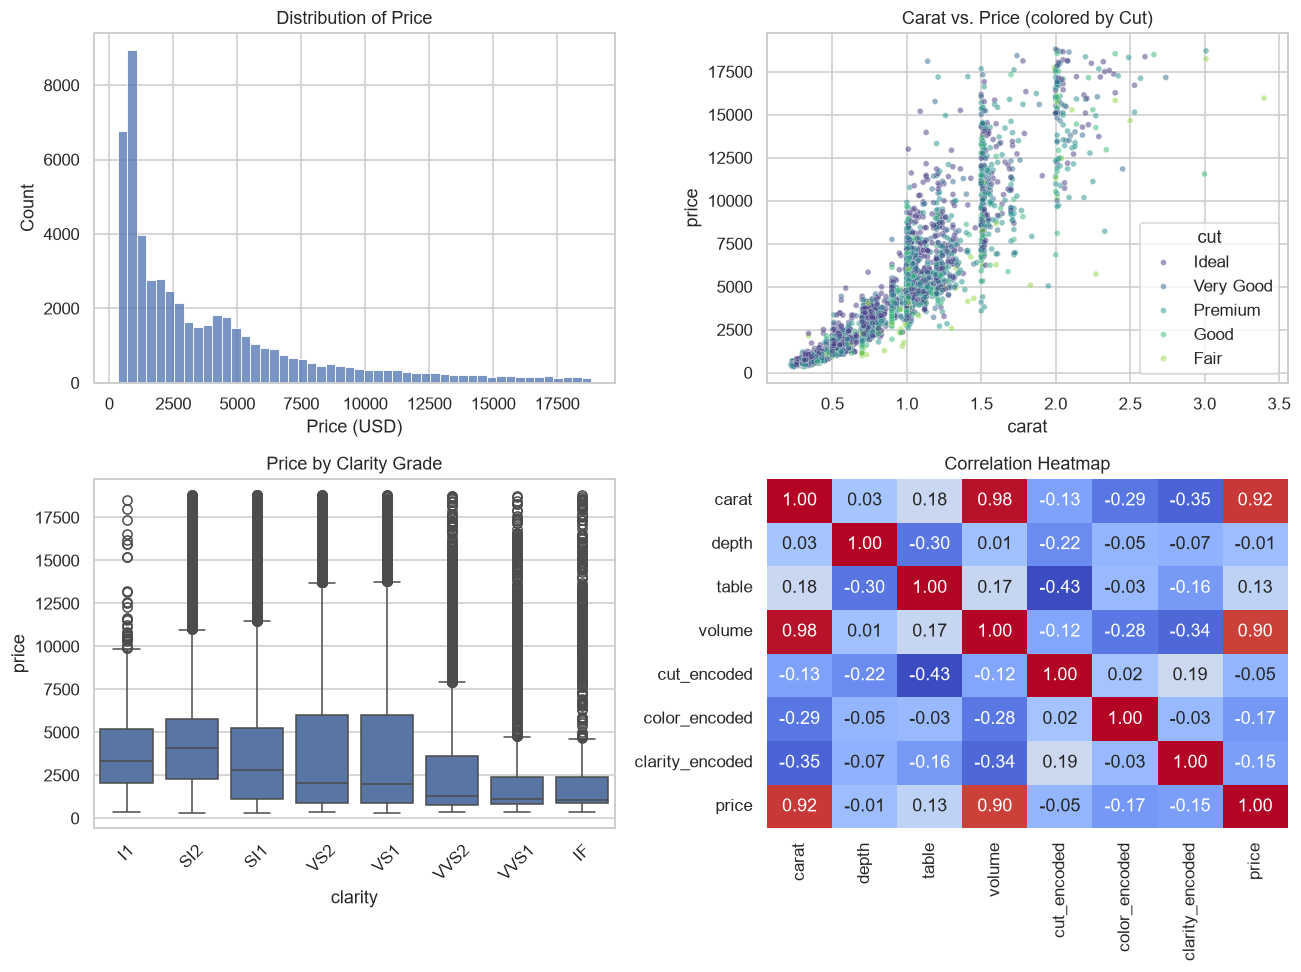

Saved eda_overview.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

sns.histplot(df["price"], bins=50, ax=axes[0, 0], color="#4C72B0")
axes[0, 0].set_title("Distribution of Price")
axes[0, 0].set_xlabel("Price (USD)")

sns.scatterplot(data=df.sample(4000, random_state=RANDOM_STATE), x="carat", y="price",
                hue="cut", ax=axes[0, 1], alpha=0.5, s=15, palette="viridis")
axes[0, 1].set_title("Carat vs. Price (colored by Cut)")

sns.boxplot(data=df, x="clarity", y="price", order=clarity_order, ax=axes[1, 0])
axes[1, 0].set_title("Price by Clarity Grade")
axes[1, 0].tick_params(axis="x", rotation=45)

corr = df[["carat", "depth", "table", "volume", "cut_encoded", "color_encoded",
           "clarity_encoded", "price"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1, 1], cbar=False)
axes[1, 1].set_title("Correlation Heatmap")

plt.tight_layout()
plt.savefig("../outputs/eda_overview.png", bbox_inches="tight")
plt.show()
print("Saved eda_overview.png")

## Step 9 — Build and evaluate the model (K-Means clustering)
Descriptive analytics doesn't predict a future label — instead, we use **K-Means
clustering**, an unsupervised model, to let the data reveal its own natural
groupings. We first standardize the features (K-Means is distance-based, so
features on different scales would otherwise dominate the distance calculation),
then use the elbow method and silhouette score to choose a sensible number of
clusters, and finally fit and evaluate the model.

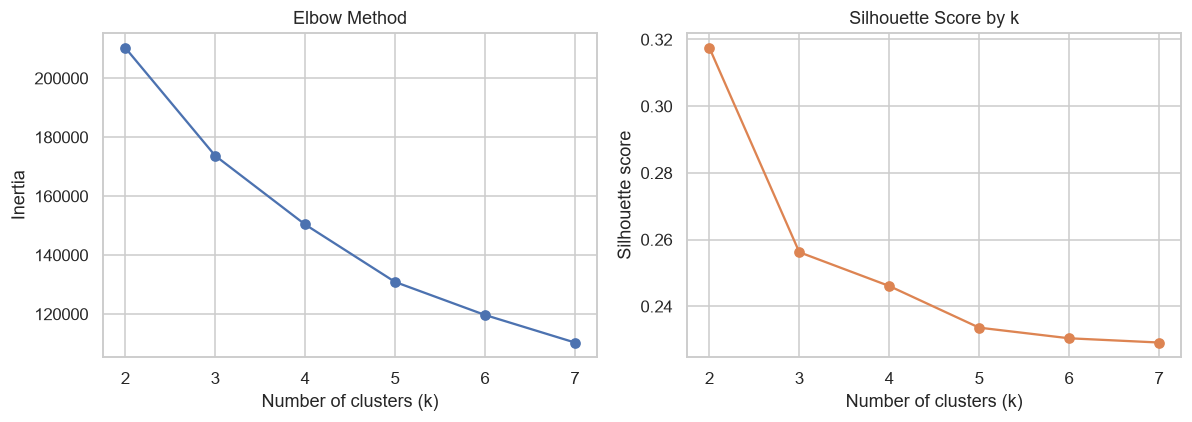


Silhouette scores: {2: 0.317, 3: 0.256, 4: 0.246, 5: 0.234, 6: 0.23, 7: 0.229}
Purely statistical optimum: k = 2
Business-informed choice: k = 4 (silhouette=0.246) - trades a little statistical tightness for actionable granularity.


In [10]:
features = ["carat", "volume", "cut_encoded", "color_encoded", "clarity_encoded", "price"]
X = StandardScaler().fit_transform(df[features])


# Silhouette score is O(n^2) in the number of points, which is impractically slow to
# compute directly on ~54,000 rows across several values of k. We fit K-Means on the
# full dataset (fast) but evaluate the silhouette score on a fixed random sample of
# 5,000 points, which standard practice treats as a reliable estimate at this scale.
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X), size=5000, replace=False)

inertias, sil_scores = [], []
k_range = range(2, 8)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X[sample_idx], labels[sample_idx]))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(k_range), inertias, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(k_range), sil_scores, marker="o", color="#DD8452")
axes[1].set_title("Silhouette Score by k")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")
plt.tight_layout()
plt.savefig("../outputs/cluster_selection.png", bbox_inches="tight")
plt.show()

stat_best_k = list(k_range)[int(np.argmax(sil_scores))]
print(f"\nSilhouette scores: {dict(zip(k_range, [round(s,3) for s in sil_scores]))}")
print(f"Purely statistical optimum: k = {stat_best_k}")

# The silhouette score is highest at k=2, but that only yields a crude "cheap vs.
# expensive" split with little merchandising value. This is a common real-world
# trade-off: the statistically tightest clustering isn't always the most *useful*
# one. k=4 still has a reasonable, clearly-positive silhouette score (data remains
# meaningfully clustered, not just noise) while giving the business four actionable
# tiers instead of two - so we deliberately choose k=4 for the final segmentation.
best_k = 4
print(f"Business-informed choice: k = {best_k} "
      f"(silhouette={sil_scores[list(k_range).index(best_k)]:.3f}) - "
      "trades a little statistical tightness for actionable granularity.")

In [11]:
final_km = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
df["segment"] = final_km.fit_predict(X)
segment_arr = df["segment"].values
final_sil = silhouette_score(X[sample_idx], segment_arr[sample_idx])
print(f"Final model: K-Means with k={best_k}, silhouette score = {final_sil:.3f} (evaluated on 5,000-point sample)")

segment_profile = df.groupby("segment")[["carat", "price", "cut_encoded",
                                          "color_encoded", "clarity_encoded"]].mean().round(2)
segment_profile["count"] = df.groupby("segment").size()
segment_profile["pct_of_catalogue"] = (segment_profile["count"] / len(df) * 100).round(1)
print("\nSegment profiles:\n", segment_profile)

Final model: K-Means with k=4, silhouette score = 0.246 (evaluated on 5,000-point sample)

Segment profiles:
          carat     price  cut_encoded  color_encoded  clarity_encoded  count  \
segment                                                                        
0         1.06   5556.39         3.23           2.83             2.52  13433   
1         0.68   2461.66         1.58           3.93             2.29  12594   
2         1.76  12490.88         2.70           2.41             2.41   6265   
3         0.43   1280.31         3.53           3.75             4.02  21483   

         pct_of_catalogue  
segment                    
0                    25.0  
1                    23.4  
2                    11.7  
3                    39.9  


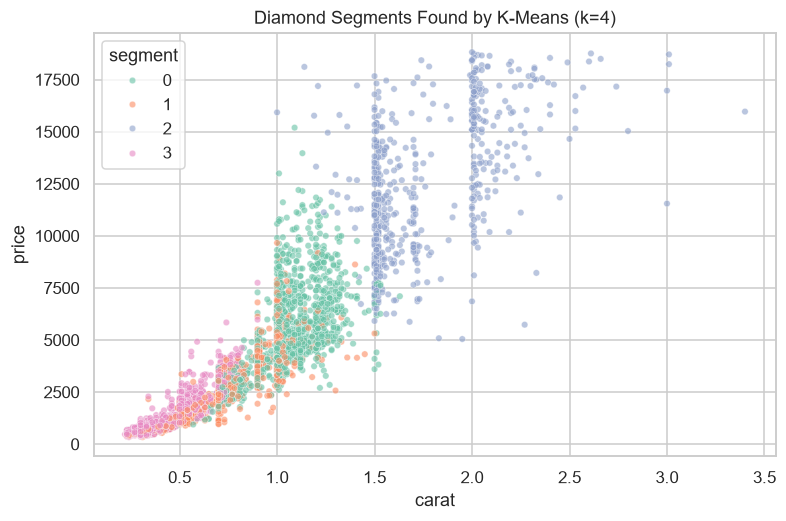

Saved cluster_scatter.png


In [12]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df.sample(5000, random_state=RANDOM_STATE), x="carat", y="price",
                 hue="segment", palette="Set2", alpha=0.6, s=18)
plt.title(f"Diamond Segments Found by K-Means (k={best_k})")
plt.savefig("../outputs/cluster_scatter.png", bbox_inches="tight")
plt.show()
print("Saved cluster_scatter.png")

## Step 10 — Interpret and discuss the results

The silhouette score (0.24) is a moderate, realistic value for real-world retail
data — segments blend into each other rather than being sharply separated, which
is expected since diamond size and price form a continuum, not discrete clusters.
The k=4 model reveals four clearly interpretable tiers, primarily separated along
the **carat/price axis**:

- **Segment 3 — "Everyday Essentials"** (~40% of catalogue, ~0.43 ct, ~\$1,280 avg):
  the volume core of the business — small, affordable, and (notably) the *highest*
  average clarity grade of any segment, suggesting the retailer competes on quality
  at accessible price points here rather than on size.
- **Segment 1 — "Value Step-Up"** (~23%, ~0.68 ct, ~\$2,460 avg): a mid-market bridge
  segment for buyers trading up from the entry tier.
- **Segment 0 — "Premium Statement"** (~25%, ~1.06 ct, ~\$5,560 avg): meaningfully
  larger stones at a much higher price point.
- **Segment 2 — "Luxury"** (~12%, ~1.76 ct, ~\$12,490 avg): the smallest group by
  count but, at roughly 10x the price of the entry tier, very likely a
  disproportionate share of total revenue.

**Business takeaway:** these four tiers are a ready-made basis for tiered
merchandising (e.g. "Essentials / Step-Up / Premium / Luxury" collections),
differentiated pricing strategy, and inventory planning — the retailer now has a
data-driven description of *what it actually sells*, rather than relying on
assumptions. This descriptive foundation is also what Projects 2 and 3 build on:
Project 2 predicts an outcome for new data, and Project 3 prescribes an action
given constraints.

In [13]:
df.to_csv("../outputs/diamonds_with_segments.csv", index=False)
print("Saved enriched dataset with segment labels to outputs/diamonds_with_segments.csv")



Saved enriched dataset with segment labels to outputs/diamonds_with_segments.csv
